<a href="https://colab.research.google.com/github/abdallahNageh/Desktop-Hotel-Reservation-System/blob/main/kws_quantization_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Post-Training Quantization of Lightweight Keyword-Spotting Models

Compares 3 small architectures (**CNN, DS-CNN, GRU**) under 4 post-training quantization variants (**fp32, fp16, int8 dynamic-range, int8 full-integer**) on Google Speech Commands (12-class setup), measuring **accuracy, model size (KB) and single-sample CPU latency (ms)**.

**How to run (Colab):**
1. Run the install cell, then the config cell with `SMOKE = True` to test the whole pipeline on random data (a few minutes).
2. Set `SMOKE = False` and run all cells for the real experiment (3 seeds; roughly 1-2 hours, a GPU runtime helps for training).

Outputs are saved in `results/`: `results_raw.csv`, `results_summary.csv`, `acc_vs_size.png`.

In [2]:
   %pip install -q -U "protobuf>=6.31.1" tensorflow-datasets pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 85.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have prot

## 1. Configuration

In [4]:
SMOKE = False          # True = tiny random-data run to test the pipeline
EPOCHS = 25            # max epochs (early stopping is on)
SEEDS = [0, 1, 2]      # repeat everything per seed, report mean/std
OUT = "results"        # output folder


## 2. Imports and constants

In [5]:
import os
import time

import numpy as np
import pandas as pd
import tensorflow as tf

SAMPLE_RATE = 16000
N_MELS = 40
NUM_CLASSES = 12  # 10 keywords + silence + unknown (tfds speech_commands)
INPUT_SHAPE = (98, N_MELS, 1)
VARIANTS = ["fp32", "fp16", "int8_dynamic", "int8_full"]
BYTES_PER_WEIGHT = {"fp32": 4, "fp16": 2, "int8_dynamic": 1, "int8_full": 1}


## 3. Data (log-mel features from Speech Commands)

In [6]:
def log_mel(audio):
    """int16-range audio (variable length) -> (98, 40) log-mel features."""
    audio = tf.cast(audio, tf.float32) / 32768.0
    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])
    audio.set_shape([SAMPLE_RATE])
    stft = tf.signal.stft(audio, frame_length=480, frame_step=160, fft_length=512)
    power = tf.square(tf.abs(stft))  # (98, 257)
    mel_w = tf.signal.linear_to_mel_weight_matrix(
        N_MELS, 257, SAMPLE_RATE, 20.0, 7600.0)
    mel = tf.matmul(power, mel_w)
    feats = tf.math.log(mel + 1e-6)
    feats.set_shape([98, N_MELS])
    return feats


def load_split(split):
    import tensorflow_datasets as tfds
    ds = tfds.load("speech_commands", split=split)
    ds = ds.map(lambda ex: (log_mel(ex["audio"]), ex["label"]),
                num_parallel_calls=tf.data.AUTOTUNE).batch(512)
    X, y = [], []
    for xb, yb in ds:
        X.append(xb.numpy())
        y.append(yb.numpy())
    return np.concatenate(X), np.concatenate(y).astype(np.int64)


def get_data(smoke=False):
    if smoke:
        rng = np.random.default_rng(0)
        def fake(n):
            return (rng.normal(size=(n, 98, N_MELS)).astype("float32"),
                    rng.integers(0, NUM_CLASSES, n))
        Xtr, ytr = fake(256); Xva, yva = fake(64); Xte, yte = fake(64)
    else:
        Xtr, ytr = load_split("train")
        Xva, yva = load_split("validation")
        Xte, yte = load_split("test")
    mean, std = Xtr.mean(), Xtr.std() + 1e-8  # statistics from train only
    prep = lambda X: ((X - mean) / std)[..., None].astype("float32")
    return prep(Xtr), ytr, prep(Xva), yva, prep(Xte), yte


## 4. Models

In [7]:
L = tf.keras.layers


def build_cnn():
    i = tf.keras.Input(INPUT_SHAPE)
    x = i
    for f in (16, 32, 64):
        x = L.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = L.BatchNormalization()(x)
        x = L.ReLU()(x)
        x = L.MaxPool2D(2)(x)
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.2)(x)
    return tf.keras.Model(i, L.Dense(NUM_CLASSES, activation="softmax")(x), name="cnn")


def build_dscnn(filters=64):
    i = tf.keras.Input(INPUT_SHAPE)
    x = L.Conv2D(filters, (10, 4), strides=(2, 2), padding="same", use_bias=False)(i)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)
    for _ in range(4):
        x = L.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
        x = L.BatchNormalization()(x)
        x = L.ReLU()(x)
        x = L.Conv2D(filters, 1, use_bias=False)(x)
        x = L.BatchNormalization()(x)
        x = L.ReLU()(x)
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.2)(x)
    return tf.keras.Model(i, L.Dense(NUM_CLASSES, activation="softmax")(x), name="dscnn")


def build_gru(units=64):
    i = tf.keras.Input(INPUT_SHAPE)
    x = L.Reshape((98, N_MELS))(i)
    x = L.GRU(units, unroll=True)(x)  # unroll: needed for static-shape TFLite conversion
    x = L.Dense(64, activation="relu")(x)
    x = L.Dropout(0.2)(x)
    return tf.keras.Model(i, L.Dense(NUM_CLASSES, activation="softmax")(x), name="gru")


MODELS = {"cnn": build_cnn, "dscnn": build_dscnn, "gru": build_gru}


def train(model, data, epochs):
    Xtr, ytr, Xva, yva = data[:4]
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = [tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=0),
          tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs,
              batch_size=128, callbacks=cb, verbose=2)


## 5. Quantization (TFLite) and evaluation

In [8]:

def to_tflite(model, variant, rep_x):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    if variant == "fp32":
        pass
    elif variant == "fp16":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_types = [tf.float16]
    elif variant == "int8_dynamic":  # int8 weights, float activations
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif variant == "int8_full":  # int8 weights + activations
        conv.optimizations = [tf.lite.Optimize.DEFAULT]

        def rep():
            for k in range(len(rep_x)):
                yield [rep_x[k:k + 1]]
        conv.representative_dataset = rep
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.int8
        conv.inference_output_type = tf.int8
    return conv.convert()


def make_interpreter(tfl):
    it = tf.lite.Interpreter(model_content=tfl, num_threads=1)
    it.allocate_tensors()
    return it


def _feed(it, x):
    inp = it.get_input_details()[0]
    if inp["dtype"] == np.int8:
        s, z = inp["quantization"]
        x = np.clip(np.round(x / s + z), -128, 127).astype(np.int8)
    it.set_tensor(inp["index"], x)


def tflite_accuracy(it, X, y):
    out = it.get_output_details()[0]["index"]
    correct = 0
    for k in range(len(X)):
        _feed(it, X[k:k + 1])
        it.invoke()
        correct += int(np.argmax(it.get_tensor(out)) == y[k])
    return correct / len(X)


def tflite_latency_ms(it, X, n=200, warmup=20):
    n = min(n, len(X))
    for k in range(min(warmup, n)):
        _feed(it, X[k:k + 1]); it.invoke()
    times = []
    for k in range(n):
        _feed(it, X[k:k + 1])
        t0 = time.perf_counter()
        it.invoke()
        times.append((time.perf_counter() - t0) * 1e3)
    return float(np.median(times))


## 6. Run the experiments
Trains every model per seed, converts it to the 4 variants, and logs accuracy / size / latency. `results_raw.csv` is updated after every row, so partial results survive a disconnect.

In [9]:
%pip install -q importlib_resources

In [10]:
!rm -rf /root/tensorflow_datasets/speech_commands

In [11]:
os.makedirs(OUT, exist_ok=True)
epochs, seeds = (1, [0]) if SMOKE else (EPOCHS, SEEDS)

data = get_data(SMOKE)
Xtr, ytr, Xva, yva, Xte, yte = data
rep_x = Xtr[np.random.default_rng(0).choice(len(Xtr), min(200, len(Xtr)), replace=False)]
print(f"train={len(Xtr)} val={len(Xva)} test={len(Xte)}")

rows = []
for seed in seeds:
    for name, builder in MODELS.items():
        tf.keras.utils.set_random_seed(seed)
        model = builder()
        print(f"\n=== seed {seed} | {name} | {model.count_params():,} params ===")
        train(model, data, epochs)
        for variant in VARIANTS:
            row = dict(seed=seed, model=name, variant=variant,
                       params=model.count_params(), acc=np.nan,
                       weights_kb=model.count_params() * BYTES_PER_WEIGHT[variant] / 1024,
                       size_kb=np.nan, latency_ms=np.nan, status="ok")
            try:
                tfl = to_tflite(model, variant, rep_x)
                it = make_interpreter(tfl)
                row["size_kb"] = len(tfl) / 1024
                row["acc"] = tflite_accuracy(it, Xte, yte)
                row["latency_ms"] = tflite_latency_ms(it, Xte)
            except Exception as e:  # e.g. full-int8 unsupported for some ops
                row["status"] = f"failed: {type(e).__name__}"
                print(f"  [{variant}] {row['status']}: {str(e)[:150]}")
            print(f"  {variant:13s} acc={row['acc']:.4f} "
                  f"size={row['size_kb']:.1f}KB lat={row['latency_ms']:.3f}ms")
            rows.append(row)
            pd.DataFrame(rows).to_csv(f"{OUT}/results_raw.csv", index=False)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.13/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


...

  fp16          acc=0.9104 size=353.8KB lat=0.653ms
Saved artifact at '/tmp/tmpww0loj4a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 98, 40, 1), dtype=tf.float32, name='keras_tensor_153')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  136515757837008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136512725257872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757836240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757838928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757845264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757846416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757844688: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  int8_dynamic  acc=0.9090 size=337.7KB lat=0.309ms
Saved artifact at '/tmp/tmpjx18tvtj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 98, 40, 1), dtype=tf.float32, name='keras_tensor_153')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  136515757837008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136512725257872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757836240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757838928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757845264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757846416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136515757844688: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  int8_full     acc=0.9117 size=1160.2KB lat=0.261ms


In [1]:
!nvidia-smi

Thu Oct  1 08:21:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 7. Summary table (mean / std over seeds)

In [12]:
df = pd.DataFrame(rows)
ok = df[df.status == "ok"]
summ = ok.groupby(["model", "variant"]).agg(
    params=("params", "first"),
    acc_mean=("acc", "mean"), acc_std=("acc", "std"),
    size_kb=("size_kb", "mean"),
    weights_kb=("weights_kb", "first"),
    lat_mean=("latency_ms", "mean"), lat_std=("latency_ms", "std"),
    n_runs=("acc", "count")).reset_index()
summ.to_csv(f"{OUT}/results_summary.csv", index=False)
summ.round(4)


,model,variant,params,acc_mean,acc_std,size_kb,weights_kb,lat_mean,lat_std,n_runs
0,cnn,fp16,24412,0.8406,0.0242,51.6445,47.6797,0.3402,0.0895,3
1,cnn,fp32,24412,0.8408,0.0244,97.7448,95.3594,0.2973,0.0102,3
2,cnn,int8_dynamic,24412,0.8414,0.0249,31.2682,23.8398,0.3523,0.0066,3
3,cnn,int8_full,24412,0.8487,0.0252,30.8490,23.8398,0.4394,0.0090,3
4,dscnn,fp16,24332,0.9068,0.0034,52.8294,47.5234,0.5071,0.0295,3
5,dscnn,fp32,24332,0.9070,0.0035,94.7161,95.0469,0.5204,0.0292,3
6,dscnn,int8_dynamic,24332,0.9072,0.0043,42.9349,23.7617,1.5520,0.0296,3
7,dscnn,int8_full,24332,0.9102,0.0007,44.7995,23.7617,1.7894,0.3347,3
8,gru,fp16,25292,0.9029,0.0066,352.6523,49.3984,0.5415,0.0962,3
9,gru,fp32,25292,0.9029,0.0066,400.9674,98.7969,0.6168,0.2109,3


## 8. Accuracy vs. size plot

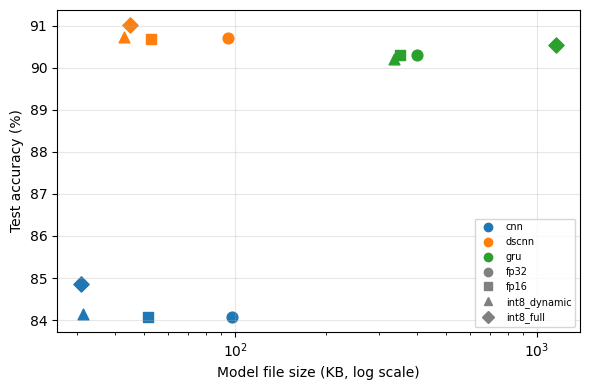

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 4))
markers = {"fp32": "o", "fp16": "s", "int8_dynamic": "^", "int8_full": "D"}
colors = {"cnn": "tab:blue", "dscnn": "tab:orange", "gru": "tab:green"}
for _, r in summ.iterrows():
    ax.scatter(r.size_kb, r.acc_mean * 100, marker=markers[r.variant],
               color=colors[r.model], s=60)
ax.set_xscale("log")
ax.set_xlabel("Model file size (KB, log scale)")
ax.set_ylabel("Test accuracy (%)")
ax.grid(alpha=0.3)
handles = [Line2D([], [], marker="o", ls="", color=c, label=m) for m, c in colors.items()]
handles += [Line2D([], [], marker=mk, ls="", color="gray", label=v) for v, mk in markers.items()]
ax.legend(handles=handles, fontsize=7)
fig.tight_layout()
fig.savefig(f"{OUT}/acc_vs_size.png", dpi=200)
plt.show()


In [14]:
   import platform, tensorflow as tf
   print("TF", tf.__version__, "| Python", platform.python_version())
   !lscpu | grep "Model name"
   !nvidia-smi --query-gpu=name --format=csv,noheader

TF 2.20.0 | Python 3.13.15
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Tesla T4


## Notes for the paper
- The GRU is built with `unroll=True` so it can be converted to TFLite; this inflates its **file size**, so report `weights_kb` (theoretical size) next to `size_kb`.
- Latency is measured on a CPU through the TFLite interpreter (single thread), not on a microcontroller. Report the CPU model and TF version.
- If a variant fails to convert, the row is kept with `status = failed: ...`; mention it as a finding.

In [15]:
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report

names = tfds.builder("speech_commands").info.features["label"].names

def dist(y):
    return np.bincount(y, minlength=len(names)) / len(y)

tab = pd.DataFrame({"class": names, "train": dist(ytr),
                    "val": dist(yva), "test": dist(yte)}).round(3)
print(tab.to_string(index=False))

print("\nval acc :", model.evaluate(Xva, yva, verbose=0)[1])
print("test acc:", model.evaluate(Xte, yte, verbose=0)[1])
pred = model.predict(Xte, batch_size=512, verbose=0).argmax(1)
print(classification_report(yte, pred, target_names=names, digits=3))

    class  train   val  test
     down  0.037 0.037 0.083
       go  0.036 0.037 0.082
     left  0.036 0.035 0.084
       no  0.037 0.040 0.083
      off  0.035 0.037 0.082
       on  0.036 0.036 0.081
    right  0.035 0.036 0.081
     stop  0.036 0.035 0.084
       up  0.034 0.035 0.087
      yes  0.038 0.039 0.086
_silence_  0.008 0.012 0.083
_unknown_  0.632 0.621 0.083

val acc : 0.956741213798523
test acc: 0.9104294180870056
              precision    recall  f1-score   support

        down      0.967     0.855     0.907       406
          go      0.949     0.878     0.912       402
        left      0.953     0.934     0.944       412
          no      0.939     0.879     0.908       405
         off      0.966     0.913     0.939       402
          on      0.957     0.896     0.926       396
       right      0.997     0.891     0.941       396
        stop      0.975     0.951     0.963       411
          up      0.948     0.906     0.927       425
         yes      0.973 